## 1. Verificarea mediului de lucru

In aceasta etapa este verificata versiunea Python utilizata pentru rularea notebook-ului. Biblioteca IBM Granite TSFM va fi instalata in acest mediu pentru utilizarea modelului preantrenat TTM.


In [18]:
import sys

print("Versiune Python:")
print(sys.version)

Versiune Python:
3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]


## 2. Importul bibliotecilor si definirea directoarelor

Sunt importate bibliotecile necesare pentru prelucrarea datelor, antrenarea modelului si calcularea metricilor. Sunt definite si directoarele in care se afla datele de intrare si rezultatele AI.


In [19]:
from pathlib import Path
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from torch.utils.data import Dataset
from transformers import (
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

from tsfm_public.toolkit.get_model import get_model
from tsfm_public import count_parameters

PROJECT_DIR = Path.cwd().parent
DATA_PATH = PROJECT_DIR / "date_prelucrate" / "ai_activitate_orara.csv"
RESULTS_DIR = PROJECT_DIR / "rezultate_ai"
MODEL_DIR = RESULTS_DIR / "ttm_finetuned"

RESULTS_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Director proiect:", PROJECT_DIR)
print("Fisier date AI:", DATA_PATH)
print("Director rezultate AI:", RESULTS_DIR)
print("GPU disponibil:", torch.cuda.is_available())

Director proiect: /home/paul/FMI-Linux/University/An2/AI/ProjectAI
Fisier date AI: /home/paul/FMI-Linux/University/An2/AI/ProjectAI/date_prelucrate/ai_activitate_orara.csv
Director rezultate AI: /home/paul/FMI-Linux/University/An2/AI/ProjectAI/rezultate_ai
GPU disponibil: True


## 3. Incarcarea datelor pentru model

Este incarcat fisierul cu date orare despre pasi si calorii. Datele sunt ordonate cronologic pentru fiecare utilizator, astfel incat modelul sa poata invata evolutia activitatii in timp.

In [20]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Fisierul ai_activitate_orara.csv nu exista. "
        "Ruleaza mai intai celulele 11 si 12 din notebook-ul de prelucrare BI."
    )

data = pd.read_csv(
    DATA_PATH,
    parse_dates=["ActivityHour"]
)

required_columns = {"Id", "ActivityHour", "StepTotal", "Calories"}
missing_columns = required_columns - set(data.columns)

if missing_columns:
    raise ValueError(
        f"Lipsesc coloanele necesare: {missing_columns}"
    )

data = data.sort_values(
    ["Id", "ActivityHour"]
).reset_index(drop=True)

print("Dimensiune date AI:", data.shape)
print("Numar utilizatori:", data["Id"].nunique())
print("Interval temporal:", data["ActivityHour"].min(), "-", data["ActivityHour"].max())

data.head()

Dimensiune date AI: (20694, 4)
Numar utilizatori: 29
Interval temporal: 2016-04-12 00:00:00 - 2016-05-12 15:00:00


,Id,ActivityHour,StepTotal,Calories
0,1503960366,2016-04-12 00:00:00,373,81
1,1503960366,2016-04-12 01:00:00,160,61
2,1503960366,2016-04-12 02:00:00,151,59
3,1503960366,2016-04-12 03:00:00,0,47
4,1503960366,2016-04-12 04:00:00,0,48


## 4. Verificarea continuitatii datelor orare

Modelul TTM necesita date ordonate la intervale regulate. In aceasta etapa este verificat faptul ca inregistrarile fiecarui utilizator sunt consecutive, din ora in ora.

In [21]:
continuity_check = data.groupby("Id")["ActivityHour"].apply(
    lambda series: (
        series.sort_values()
        .diff()
        .dropna()
        .eq(pd.Timedelta(hours=1))
        .all()
    )
)

print("Utilizatori cu serie orara continua:", continuity_check.sum())
print("Utilizatori verificati:", len(continuity_check))

if not continuity_check.all():
    problematic_users = continuity_check[
        continuity_check == False
    ].index.tolist()

    raise ValueError(
        f"Exista utilizatori cu ore lipsa in serie: {problematic_users}"
    )

print("Toate seriile orare sunt continue.")

Utilizatori cu serie orara continua: 29
Utilizatori verificati: 29
Toate seriile orare sunt continue.


## 5. Configurarea experimentului si impartirea datelor

Modelul va utiliza 512 ore anterioare pentru a prezice urmatoarele 24 de ore. Utilizatorii sunt impartiti separat in train, validation si test, pentru a evalua modelul pe persoane nevazute in timpul antrenarii.

In [22]:
SEED = 42
CONTEXT_LENGTH = 512
PREDICTION_LENGTH = 24
STRIDE = 24

TARGET_COLUMNS = ["StepTotal", "Calories"]
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"

set_seed(SEED)

series_length = data.groupby("Id").size()
eligible_ids = series_length[
    series_length >= CONTEXT_LENGTH + PREDICTION_LENGTH
].index.to_numpy().copy()

rng = np.random.default_rng(SEED)
rng.shuffle(eligible_ids)

test_ids = eligible_ids[:5]
valid_ids = eligible_ids[5:10]
train_ids = eligible_ids[10:]

train_data = data[data["Id"].isin(train_ids)].copy()
valid_data = data[data["Id"].isin(valid_ids)].copy()
test_data = data[data["Id"].isin(test_ids)].copy()

print("Utilizatori train:", len(train_ids))
print("Utilizatori validation:", len(valid_ids))
print("Utilizatori test:", len(test_ids))

print("\nID-uri test:")
print(test_ids)

Utilizatori train: 19
Utilizatori validation: 5
Utilizatori test: 5

ID-uri test:
[2320127002 5553957443 8053475328 7086361926 6117666160]


## 6. Standardizarea variabilelor de intrare

Pasi si caloriile au scari diferite, de aceea valorile sunt standardizate inainte de utilizarea modelului. Standardizarea este calculata doar pe setul de antrenare pentru a pastra evaluarea corecta.

In [23]:
scaler = StandardScaler()

scaler.fit(
    train_data[TARGET_COLUMNS]
)

train_scaled = train_data.copy()
valid_scaled = valid_data.copy()
test_scaled = test_data.copy()

train_scaled[TARGET_COLUMNS] = scaler.transform(
    train_data[TARGET_COLUMNS]
)

valid_scaled[TARGET_COLUMNS] = scaler.transform(
    valid_data[TARGET_COLUMNS]
)

test_scaled[TARGET_COLUMNS] = scaler.transform(
    test_data[TARGET_COLUMNS]
)

print("Media folosita la scalare:")
print(dict(zip(TARGET_COLUMNS, scaler.mean_)))

print("\nDeviatia standard folosita la scalare:")
print(dict(zip(TARGET_COLUMNS, scaler.scale_)))

train_scaled.head()

Media folosita la scalare:
{'StepTotal': np.float64(291.6077937472218), 'Calories': np.float64(92.85701585420063)}

Deviatia standard folosita la scalare:
{'StepTotal': np.float64(606.5158584616105), 'Calories': np.float64(51.768528979726135)}


,Id,ActivityHour,StepTotal,Calories
0,1503960366,2016-04-12 00:00:00,0.134196,-0.229039
1,1503960366,2016-04-12 01:00:00,-0.216990,-0.615374
2,1503960366,2016-04-12 02:00:00,-0.231829,-0.654008
3,1503960366,2016-04-12 03:00:00,-0.480792,-0.885809
4,1503960366,2016-04-12 04:00:00,-0.480792,-0.866492


## 7. Crearea seturilor de date pentru model

Datele sunt transformate in ferestre temporale formate din istoric si valori viitoare. Fiecare exemplu contine 512 ore de intrare si 24 de ore care trebuie prezise.

In [24]:
class FitbitForecastDataset(Dataset):
    def __init__(
        self,
        dataframe,
        context_length,
        prediction_length,
        stride,
        target_columns
    ):
        self.samples = []
        self.metadata = []

        for user_id, user_data in dataframe.groupby("Id"):
            user_data = user_data.sort_values("ActivityHour").reset_index(drop=True)

            values = user_data[target_columns].to_numpy(dtype=np.float32)
            times = user_data["ActivityHour"].to_numpy()

            max_start = len(values) - context_length - prediction_length

            for start in range(0, max_start + 1, stride):
                past_end = start + context_length
                future_end = past_end + prediction_length

                past_values = values[start:past_end]
                future_values = values[past_end:future_end]

                self.samples.append({
                    "past_values": torch.tensor(past_values, dtype=torch.float32),
                    "future_values": torch.tensor(future_values, dtype=torch.float32),
                    "past_observed_mask": torch.ones_like(
                        torch.tensor(past_values),
                        dtype=torch.bool
                    ),
                    "future_observed_mask": torch.ones_like(
                        torch.tensor(future_values),
                        dtype=torch.bool
                    ),
                    "freq_token": torch.tensor(0)
                })

                self.metadata.append({
                    "Id": user_id,
                    "ForecastStart": pd.Timestamp(times[past_end])
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]


train_dataset = FitbitForecastDataset(
    train_scaled,
    CONTEXT_LENGTH,
    PREDICTION_LENGTH,
    STRIDE,
    TARGET_COLUMNS
)

valid_dataset = FitbitForecastDataset(
    valid_scaled,
    CONTEXT_LENGTH,
    PREDICTION_LENGTH,
    STRIDE,
    TARGET_COLUMNS
)

test_dataset = FitbitForecastDataset(
    test_scaled,
    CONTEXT_LENGTH,
    PREDICTION_LENGTH,
    STRIDE,
    TARGET_COLUMNS
)

print("Ferestre train:", len(train_dataset))
print("Ferestre validation:", len(valid_dataset))
print("Ferestre test:", len(test_dataset))

if len(train_dataset) == 0 or len(valid_dataset) == 0 or len(test_dataset) == 0:
    raise ValueError("Nu exista suficiente ferestre pentru antrenare sau evaluare.")

Ferestre train: 150
Ferestre validation: 42
Ferestre test: 42


## 8. Definirea evaluarii si a modelului de referinta

Este creat un model simplu de referinta care presupune repetarea activitatii din ziua precedenta. Rezultatele modelului AI vor fi comparate cu aceasta metoda folosind metricile MAE si RMSE.

In [25]:
def get_true_values(dataset):
    return np.stack([
        sample["future_values"].numpy()
        for sample in dataset.samples
    ])


def inverse_transform_3d(values_scaled):
    original_shape = values_scaled.shape

    values_2d = values_scaled.reshape(-1, len(TARGET_COLUMNS))
    values_original = scaler.inverse_transform(values_2d)

    return values_original.reshape(original_shape)


def clip_predictions(values):
    values = values.copy()
    values[:, :, 0] = np.maximum(values[:, :, 0], 0)
    values[:, :, 1] = np.maximum(values[:, :, 1], 0)
    return values


def calculate_metrics(model_name, true_values, predicted_values):
    rows = []

    for index, column in enumerate(TARGET_COLUMNS):
        mae = mean_absolute_error(
            true_values[:, :, index].ravel(),
            predicted_values[:, :, index].ravel()
        )

        rmse = np.sqrt(
            mean_squared_error(
                true_values[:, :, index].ravel(),
                predicted_values[:, :, index].ravel()
            )
        )

        rows.append({
            "Model": model_name,
            "Variabila": column,
            "MAE": mae,
            "RMSE": rmse
        })

    return rows


true_scaled = get_true_values(test_dataset)
true_original = inverse_transform_3d(true_scaled)

baseline_scaled = np.stack([
    sample["past_values"][-PREDICTION_LENGTH:].numpy()
    for sample in test_dataset.samples
])

baseline_original = clip_predictions(
    inverse_transform_3d(baseline_scaled)
)

metrics_rows = calculate_metrics(
    "Baseline ziua precedenta",
    true_original,
    baseline_original
)

pd.DataFrame(metrics_rows)

,Model,Variabila,MAE,RMSE
0,Baseline ziua precedenta,StepTotal,398.710327,905.903658
1,Baseline ziua precedenta,Calories,30.458334,63.276667


## 9. Evaluarea modelului TTM fara antrenare suplimentara

Modelul preantrenat IBM Granite TTM este incarcat si testat direct pe datele Fitbit. Aceasta evaluare zero-shot arata performanta initiala a modelului inainte de ajustarea pe datele proiectului.

In [26]:
zero_shot_model = get_model(
    TTM_MODEL_PATH,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    num_input_channels=len(TARGET_COLUMNS),
    prediction_channel_indices=[0, 1]
)

zero_shot_trainer = Trainer(
    model=zero_shot_model,
    args=TrainingArguments(
        output_dir=str(RESULTS_DIR / "zero_shot_temp"),
        per_device_eval_batch_size=32,
        report_to=[]
    )
)

zero_shot_output = zero_shot_trainer.predict(test_dataset)

zero_shot_scaled = zero_shot_output.predictions

if isinstance(zero_shot_scaled, tuple):
    zero_shot_scaled = zero_shot_scaled[0]

zero_shot_original = clip_predictions(
    inverse_transform_3d(zero_shot_scaled)
)

metrics_rows.extend(
    calculate_metrics(
        "TTM zero-shot",
        true_original,
        zero_shot_original
    )
)

metrics_results = pd.DataFrame(metrics_rows)
metrics_results

INFO:p-126222:t-124447627473024:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-126222:t-124447627473024:get_model.py:get_model:Model path type is 2
INFO:p-126222:t-124447627473024:get_model.py:get_model:Attempting model load from ibm-granite/granite-timeseries-ttm-r2, revision = 512-48-ft-r2.1.
INFO:p-126222:t-124447627473024:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 512-48-ft-r2.1.
INFO:p-126222:t-124447627473024:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 48


,Model,Variabila,MAE,RMSE
0,Baseline ziua precedenta,StepTotal,398.710327,905.903658
1,Baseline ziua precedenta,Calories,30.458334,63.276667
2,TTM zero-shot,StepTotal,454.148376,818.943145
3,TTM zero-shot,Calories,35.740040,60.744522


## 10. Pregatirea modelului pentru fine-tuning

Este incarcat din nou modelul preantrenat, de aceasta data pentru ajustarea pe datele Fitbit. Componenta principala a modelului este inghetata, iar partea de predictie va invata relatia dintre pasi si calorii.

In [27]:
fine_tuned_model = get_model(
    TTM_MODEL_PATH,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    num_input_channels=len(TARGET_COLUMNS),
    prediction_channel_indices=[0, 1],
    decoder_mode="mix_channel"
)

print("Parametri inainte de inghetarea backbone-ului:")
print(count_parameters(fine_tuned_model))

for parameter in fine_tuned_model.backbone.parameters():
    parameter.requires_grad = False

print("\nParametri dupa inghetarea backbone-ului:")
print(count_parameters(fine_tuned_model))

INFO:p-126222:t-124447627473024:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-126222:t-124447627473024:get_model.py:get_model:Model path type is 2
INFO:p-126222:t-124447627473024:get_model.py:get_model:Attempting model load from ibm-granite/granite-timeseries-ttm-r2, revision = 512-48-ft-r2.1.
Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixe

Parametri inainte de inghetarea backbone-ului:
800324

Parametri dupa inghetarea backbone-ului:
247386


## 11. Fine-tuning pe datele Fitbit

Modelul este ajustat pe setul de antrenare si verificat periodic pe setul de validare. Antrenarea se opreste automat daca rezultatele nu se mai imbunatatesc.

In [28]:
training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    overwrite_output_dir=True,
    num_train_epochs=20,
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    report_to=[]
)

fine_tune_trainer = Trainer(
    model=fine_tuned_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ]
)

training_result = fine_tune_trainer.train()

print("Fine-tuning finalizat.")

Epoch,Training Loss,Validation Loss
1,1.767300,2.931295
2,1.322500,2.305614
3,1.085900,1.965430
4,0.968500,1.799223
5,0.955200,1.730410
6,0.917300,1.704814
7,0.881300,1.692572
8,0.898900,1.686755
9,0.894600,1.683852
10,0.838400,1.680816


/home/paul/FMI-Linux/University/An2/AI/ProjectAI/.venv/lib/python3.12/site-packages/transformers/trainer.py:4380: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/home/paul/FMI-Linux/University/An2/AI/ProjectAI/.venv/lib/python3.12/site-packages/transformers/trainer.py:4380: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/home/paul/FMI-Linux/University/An2/AI/ProjectAI/.venv/lib/python3.12/site-packages/transformers/trainer.py:4380: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/home/paul/FMI-Linux/University/An2/AI/ProjectAI/.venv/lib/python3.12/site-p

Fine-tuning finalizat.


## 12. Evaluarea modelului ajustat

Modelul ajustat este testat pe utilizatori care nu au fost folositi la antrenare. Rezultatele sunt comparate cu baseline-ul si cu modelul TTM utilizat fara fine-tuning.

In [29]:
fine_tuned_output = fine_tune_trainer.predict(test_dataset)

fine_tuned_scaled = fine_tuned_output.predictions

if isinstance(fine_tuned_scaled, tuple):
    fine_tuned_scaled = fine_tuned_scaled[0]

fine_tuned_original = clip_predictions(
    inverse_transform_3d(fine_tuned_scaled)
)

metrics_rows.extend(
    calculate_metrics(
        "TTM fine-tuned",
        true_original,
        fine_tuned_original
    )
)

metrics_results = pd.DataFrame(metrics_rows)

metrics_results = metrics_results.sort_values(
    ["Variabila", "RMSE"]
).reset_index(drop=True)

metrics_results

,Model,Variabila,MAE,RMSE
0,TTM fine-tuned,Calories,36.490452,59.439363
1,TTM zero-shot,Calories,35.740040,60.744522
2,Baseline ziua precedenta,Calories,30.458334,63.276667
3,TTM fine-tuned,StepTotal,377.184601,720.042577
4,TTM zero-shot,StepTotal,454.148376,818.943145
5,Baseline ziua precedenta,StepTotal,398.710327,905.903658


## 13. Salvarea rezultatelor de evaluare

Metricile obtinute pentru cele trei metode sunt salvate intr-un fisier CSV. Acest fisier poate fi utilizat in documentatie si in dashboard-ul Power BI.

In [30]:
METRICS_PATH = RESULTS_DIR / "metrici_modele_ttm.csv"

metrics_results.to_csv(
    METRICS_PATH,
    index=False
)

print("Metricile au fost salvate in:")
print(METRICS_PATH)

metrics_results

Metricile au fost salvate in:
/home/paul/FMI-Linux/University/An2/AI/ProjectAI/rezultate_ai/metrici_modele_ttm.csv


,Model,Variabila,MAE,RMSE
0,TTM fine-tuned,Calories,36.490452,59.439363
1,TTM zero-shot,Calories,35.740040,60.744522
2,Baseline ziua precedenta,Calories,30.458334,63.276667
3,TTM fine-tuned,StepTotal,377.184601,720.042577
4,TTM zero-shot,StepTotal,454.148376,818.943145
5,Baseline ziua precedenta,StepTotal,398.710327,905.903658


## 14. Exportul predictiilor pentru Power BI

Predictiile obtinute pentru utilizatorii de test sunt organizate intr-un tabel final. Fisierul rezultat permite compararea valorilor reale cu predictiile celor trei metode in dashboard-ul BI.

In [31]:
export_rows = []

for sample_index, metadata in enumerate(test_dataset.metadata):
    user_id = metadata["Id"]
    forecast_start = metadata["ForecastStart"]

    for horizon in range(PREDICTION_LENGTH):
        prediction_time = forecast_start + pd.Timedelta(hours=horizon)

        export_rows.append({
            "Id": user_id,
            "ActivityHour": prediction_time,
            "ForecastHour": horizon + 1,

            "ActualSteps": true_original[sample_index, horizon, 0],
            "ActualCalories": true_original[sample_index, horizon, 1],

            "PredictedSteps_Baseline": baseline_original[sample_index, horizon, 0],
            "PredictedCalories_Baseline": baseline_original[sample_index, horizon, 1],

            "PredictedSteps_TTM_ZeroShot": zero_shot_original[sample_index, horizon, 0],
            "PredictedCalories_TTM_ZeroShot": zero_shot_original[sample_index, horizon, 1],

            "PredictedSteps_TTM_FineTuned": fine_tuned_original[sample_index, horizon, 0],
            "PredictedCalories_TTM_FineTuned": fine_tuned_original[sample_index, horizon, 1]
        })

predictions_export = pd.DataFrame(export_rows)

PREDICTIONS_PATH = RESULTS_DIR / "predictii_ttm.csv"

predictions_export.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print("Predictiile au fost salvate in:")
print(PREDICTIONS_PATH)

print("Dimensiune tabel predictii:", predictions_export.shape)

predictions_export.head()

Predictiile au fost salvate in:
/home/paul/FMI-Linux/University/An2/AI/ProjectAI/rezultate_ai/predictii_ttm.csv
Dimensiune tabel predictii: (1008, 11)


,Id,ActivityHour,ForecastHour,ActualSteps,ActualCalories,PredictedSteps_Baseline,PredictedCalories_Baseline,PredictedSteps_TTM_ZeroShot,PredictedCalories_TTM_ZeroShot,PredictedSteps_TTM_FineTuned,PredictedCalories_TTM_FineTuned
0,2320127002,2016-05-03 08:00:00,1,473.000000,101.000000,0.0,55.0,574.568481,98.310295,577.890869,101.595222
1,2320127002,2016-05-03 09:00:00,2,-0.000031,56.000004,0.0,55.0,426.113708,87.491463,430.560669,93.114433
2,2320127002,2016-05-03 10:00:00,3,-0.000031,55.000000,0.0,55.0,334.149719,80.496040,297.370972,85.976868
3,2320127002,2016-05-03 11:00:00,4,-0.000031,55.000000,0.0,55.0,289.123718,77.163071,189.660980,79.497391
4,2320127002,2016-05-03 12:00:00,5,-0.000031,55.000000,0.0,55.0,269.743561,75.937851,173.706955,77.155952


## 16. Vizualizarea predictiilor pentru pasi

Este afisata comparatia dintre numarul real de pasi si predictiile obtinute pentru un exemplu din setul de test. Graficul permite observarea vizuala a comportamentului celor trei metode.

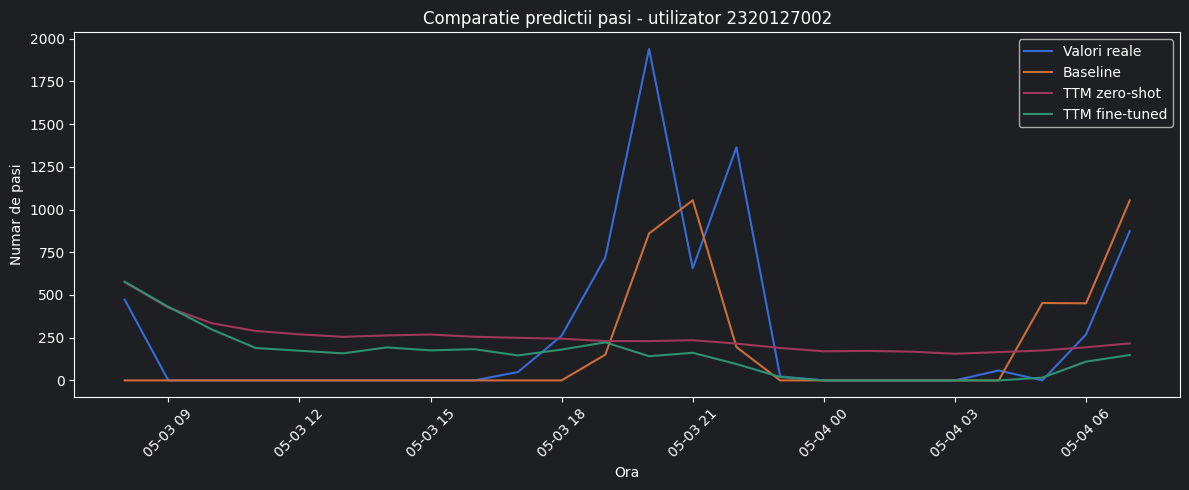

In [32]:
example_user = predictions_export["Id"].iloc[0]

example_data = predictions_export[
    predictions_export["Id"] == example_user
].head(PREDICTION_LENGTH)

plt.figure(figsize=(12, 5))

plt.plot(
    example_data["ActivityHour"],
    example_data["ActualSteps"],
    label="Valori reale"
)

plt.plot(
    example_data["ActivityHour"],
    example_data["PredictedSteps_Baseline"],
    label="Baseline"
)

plt.plot(
    example_data["ActivityHour"],
    example_data["PredictedSteps_TTM_ZeroShot"],
    label="TTM zero-shot"
)

plt.plot(
    example_data["ActivityHour"],
    example_data["PredictedSteps_TTM_FineTuned"],
    label="TTM fine-tuned"
)

plt.title(f"Comparatie predictii pasi - utilizator {example_user}")
plt.xlabel("Ora")
plt.ylabel("Numar de pasi")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 17. Vizualizarea predictiilor pentru calorii

Este afisata comparatia dintre caloriile reale si valorile prezise pentru acelasi exemplu de test. Graficul completeaza evaluarea numerica realizata prin MAE si RMSE.

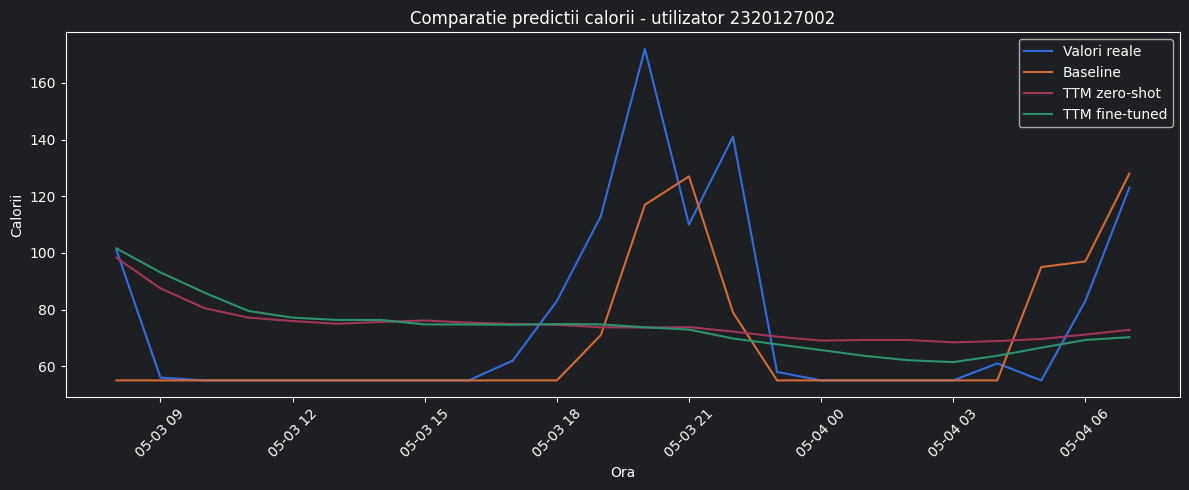

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(
    example_data["ActivityHour"],
    example_data["ActualCalories"],
    label="Valori reale"
)

plt.plot(
    example_data["ActivityHour"],
    example_data["PredictedCalories_Baseline"],
    label="Baseline"
)

plt.plot(
    example_data["ActivityHour"],
    example_data["PredictedCalories_TTM_ZeroShot"],
    label="TTM zero-shot"
)

plt.plot(
    example_data["ActivityHour"],
    example_data["PredictedCalories_TTM_FineTuned"],
    label="TTM fine-tuned"
)

plt.title(f"Comparatie predictii calorii - utilizator {example_user}")
plt.xlabel("Ora")
plt.ylabel("Calorii")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 18. Interpretarea rezultatelor obtinute

Este identificat automat modelul cu cea mai mica eroare pentru fiecare variabila analizata. Interpretarea finala trebuie realizata pe baza metricilor obtinute, fara a presupune dinainte ca fine-tuning-ul este mai performant.

In [34]:
best_models = (
    metrics_results
    .sort_values("RMSE")
    .groupby("Variabila", as_index=False)
    .first()
)

print("Cel mai bun model pentru fiecare variabila, pe baza RMSE:")
print(best_models[["Variabila", "Model", "RMSE"]])

for _, row in best_models.iterrows():
    print(
        f"\nPentru {row['Variabila']}, cea mai buna metoda este "
        f"{row['Model']}, cu RMSE = {row['RMSE']:.2f}."
    )

Cel mai bun model pentru fiecare variabila, pe baza RMSE:
   Variabila           Model        RMSE
0   Calories  TTM fine-tuned   59.439363
1  StepTotal  TTM fine-tuned  720.042577

Pentru Calories, cea mai buna metoda este TTM fine-tuned, cu RMSE = 59.44.

Pentru StepTotal, cea mai buna metoda este TTM fine-tuned, cu RMSE = 720.04.
